# Crude-Seasonality
### Does crude really rally into summer driving season every year?

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Every year?: Busted](https://img.shields.io/badge/Every_year%3F-Busted-8b949e?style=flat-square)

The story: refineries switch to summer blends in spring, driving demand peaks, so April–June should be a reliably bullish window for crude oil. The data says: yes-ish, sometimes, but nowhere near reliably enough to make a calendar trading rule out of it — especially for the actual investable proxy (energy equities), where the timer is a disaster.

> **Plain-language layer.** The per-month t-stats and the timer math are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> Not investment advice. Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (crude_seasonality/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from crude_seasonality import data, strategy as st
from quantlab import repro
d = repro.as_of(data.fetch_data())   # cache-first (examples/verify.py --fetch); hole-free monthly grid
rf = d["tbill"]
timer_cl = st.seasonal_timer(d["crude"], tbill=rf)
bh_cl = st.buy_hold(d["crude"])
timer_xle = st.seasonal_timer(d["energy"], tbill=rf)
bh_xle = st.buy_hold(d["energy"])
ms = st.month_stats(d["crude"])
sa = st.spring_autumn_tstat(d["crude"])


## The answer first

| The claim | The data (2000–2026, 309 months) |
|---|---|
| "Spring is reliably bullish for crude" | Spring (Apr–Jun) mean **+2.76%**, autumn −1.62%, spread **t = 2.47** — real but marginal. |
| "Trade it with a calendar rule" | Energy-equity timer (XLE) Sharpe **0.04** vs buy-and-hold **0.35** (excess of T-bill) — a near-total destruction of edge. |
| "Every year" | Insignificant in 2000–2012 (t = 1.42). Pattern is a post-shale phenomenon, not a timeless law. |

## 1 · The claim

The driving-season narrative: US gasoline demand peaks May–August, refineries must build crude inventory in spring to meet summer demand, and this seasonal buying pressure creates a reliable spring rally in crude. The flip side: autumn refinery maintenance season reduces runs, crude demand falls, and prices weaken August–November. A calendar-systematic trader could buy crude in April and short it in August.

## 2 · So what?

If the pattern were real and robust, a simple calendar rule — buy USO every April, exit June, short August, cover November — would harvest a seasonal premium with no need for fundamental views. Seasonal anomalies are among the most scrutinised and arbitraged away calendar effects on the bench; the question is whether this one survived.

## 3 · How would we even know?

Monthly t-stats for each calendar month (is each month's average return significantly different from zero?), a Welch t-test comparing spring months to autumn months, and a timer (long Apr–Jun, short Aug–Nov, T-bill otherwise) raced against buy-and-hold on both crude (CL=F) and energy equities (XLE). Bonferroni correction for 12 simultaneous monthly tests raises the effective threshold to |t| ≈ 3.

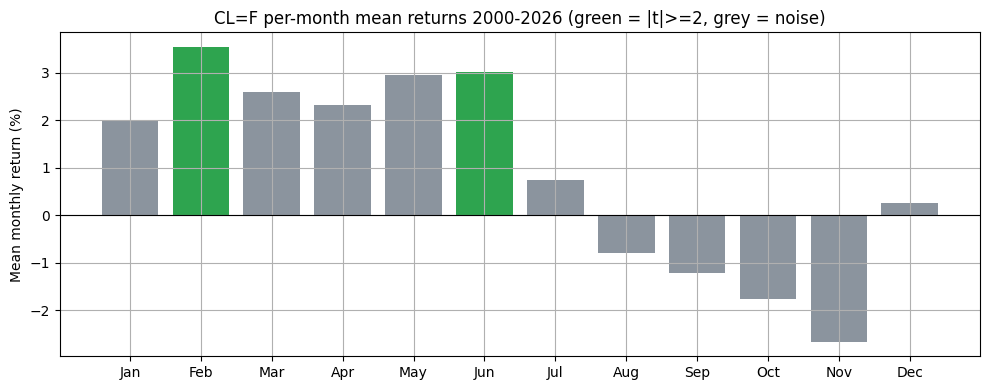

Spring (Apr-Jun): 2.76%  n=77
Autumn (Aug-Nov): -1.62%  n=103
Spring vs Autumn: t=2.47  (|t|>=2 bar, Bonferroni threshold ~3)


In [2]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
fig,ax = plt.subplots(figsize=(10,4))
means = [ms.loc[m,'mean']*100 for m in range(1,13)]
tstats = [ms.loc[m,'tstat'] for m in range(1,13)]
colors = ['#2ea44f' if abs(t)>=2 else '#8b949e' for t in tstats]
ax.bar(month_names, means, color=colors)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Mean monthly return (%)')
ax.set_title('CL=F per-month mean returns 2000-2026 (green = |t|>=2, grey = noise)')
plt.tight_layout(); plt.show()
print('Spring (Apr-Jun):', f"{sa['spring_mean']*100:.2f}%  n={sa['n_spring']}")
print('Autumn (Aug-Nov):', f"{sa['autumn_mean']*100:.2f}%  n={sa['n_autumn']}")
print(f'Spring vs Autumn: t={sa["tstat"]:.2f}  (|t|>=2 bar, Bonferroni threshold ~3)')

## 4 · The teardown

The bar chart shows the expected shape — spring months positive, autumn months negative — but only two months (February, June) nominally pass |t| ≥ 2, and neither survives Bonferroni adjustment. The spread between spring and autumn groups clears the bar (t = 2.47) but collapses in the pre-shale decade (2000–2012: t = 1.42).

,cagr,sharpe,max_drawdown
crude timer (CL=F),0.123,0.460,-0.555
buy & hold CL=F,0.038,0.238,-0.865
energy timer (XLE),0.007,0.037,-0.574
buy & hold XLE,0.078,0.354,-0.640


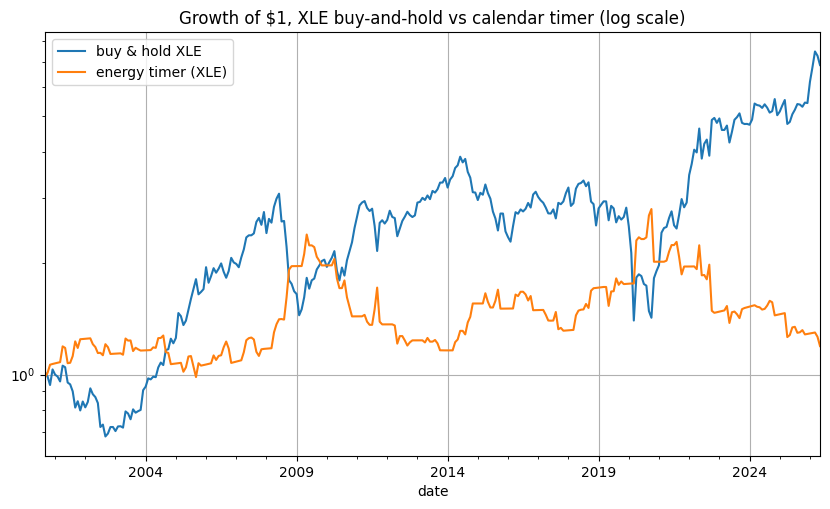

In [3]:
# Timer vs buy-and-hold for energy equities (XLE) — the investable case
rows = {
    'crude timer (CL=F)': st.summary(timer_cl, rf=rf),
    'buy & hold CL=F': st.summary(bh_cl, rf=rf),
    'energy timer (XLE)': st.summary(timer_xle, rf=rf),
    'buy & hold XLE': st.summary(bh_xle, rf=rf),
}
display(pd.DataFrame(rows).T[['cagr','sharpe','max_drawdown']].round(3))
eq_bh = (1+bh_xle).cumprod(); eq_t = (1+timer_xle).cumprod()
ax = eq_bh.plot(label='buy & hold XLE', lw=1.5)
eq_t.plot(ax=ax, label='energy timer (XLE)', lw=1.5)
ax.set_yscale('log'); ax.set_title('Growth of $1, XLE buy-and-hold vs calendar timer (log scale)')
ax.legend(); plt.show()

**Read it plainly.** The calendar timer destroys the XLE investor: Sharpe 0.04 vs 0.35. The seasonal story in crude futures is a weak historical tendency — not a tradable rule for the investable asset.

## 5 · The verdict

**Signal: Weak** — the spring-vs-autumn spread clears |t| = 2.47 on the full sample but fails Bonferroni and is regime-dependent. **Tradability: Mirage** — the XLE timer earns Sharpe 0.04 vs 0.35 for buy-and-hold. **"Every year"? Busted.**

## 6 · Could you actually trade it?

You could code the crude calendar in three lines — and you'd underperform a do-nothing XLE investor by a devastating margin. The driving-season narrative is compelling but the numbers don't back it up as a reliable annual calendar.

## 7 · Going further

Forks: (a) test on gasoline futures (RB=F) where the seasonal demand is more direct; (b) crack-spread seasonality (refining margin); (c) condition on inventory levels (EIA weekly storage) rather than the calendar. Companion: [49 Black-Gold](../../49-black-gold/) (oil→equity cross-asset).